In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv("eCommerce_Customer_support_data.csv")
print(df.head())

                              Unique id channel_name         category  \
0  7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1  b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2  200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3  eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4  ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   

                   Sub-category Customer Remarks  \
0                Life Insurance              NaN   
1  Product Specific Information              NaN   
2             Installation/demo              NaN   
3        Reverse Pickup Enquiry              NaN   
4                    Not Needed              NaN   

                               Order_id order_date_time Issue_reported at  \
0  c27c9bb4-fa36-4140-9f1f-21009254ffdb             NaN  01/08/2023 11:13   
1  d406b0c7-ce17-4654-b9de-f08d421254bd             NaN  01/08/2023 12:52   
2  c273368d-b961-

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [8]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


In [9]:
df = df.dropna()

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [11]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
13565,2,1,2,2,3,0,34,1,1,0,9,0,899.0,367.0,12,5,2,0,2,5
13603,33,1,2,2,12,31,37,0,0,0,27,0,899.0,604.0,16,4,1,1,2,2
18445,8,1,2,2,1,17,35,7,7,2,0,0,868.0,233.0,4,5,2,0,2,4
19678,12,1,2,2,7,37,1,5,4,1,11,0,899.0,458.0,4,5,2,0,2,5
20080,32,1,0,1,24,16,8,2,2,1,5,0,799.0,362.0,18,5,2,0,0,5


In [13]:
print(df.columns)

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')


In [15]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [17]:
X = df.drop("CSAT_Score", axis=1)

y = df["CSAT_Score"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
df = df.drop([
    'Unique_id',
    'Order_id',
    'Agent_name',
    'Supervisor',
    'Manager',
    'Customer_Remarks',
    'order_date_time',
    'Survey_response_Date'
], axis=1)

In [20]:
df.head()

,channel_name,category,Sub-category,Issue_reported_at,issue_responded,Customer_City,Product_category,Item_price,connected_handling_time,Tenure_Bucket,Agent_Shift,CSAT_Score
13565,1,2,2,1,1,9,0,899.0,367.0,0,2,5
13603,1,2,2,0,0,27,0,899.0,604.0,1,2,2
18445,1,2,2,7,7,0,0,868.0,233.0,0,2,4
19678,1,2,2,5,4,11,0,899.0,458.0,0,2,5
20080,1,0,1,2,2,5,0,799.0,362.0,0,0,5


In [21]:
df['Issue_reported_at'] = pd.to_datetime(df['Issue_reported_at'])
df['issue_responded'] = pd.to_datetime(df['issue_responded'])

df['response_time'] = (df['issue_responded'] - df['Issue_reported_at']).dt.total_seconds()

In [22]:
df = df.drop(['Issue_reported_at','issue_responded'], axis=1)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [24]:
df.head()

,channel_name,category,Sub-category,Customer_City,Product_category,Item_price,connected_handling_time,Tenure_Bucket,Agent_Shift,CSAT_Score,response_time
13565,1,2,2,9,0,899.0,367.0,0,2,5,0.000000e+00
13603,1,2,2,27,0,899.0,604.0,1,2,2,0.000000e+00
18445,1,2,2,0,0,868.0,233.0,0,2,4,0.000000e+00
19678,1,2,2,11,0,899.0,458.0,0,2,5,-1.000000e-09
20080,1,0,1,5,0,799.0,362.0,0,0,5,0.000000e+00


In [25]:
X = df.drop("CSAT_Score", axis=1)

y = df["CSAT_Score"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

RandomForestRegressor()

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.48161250000000017
R2 Score: 0.005703225806451218


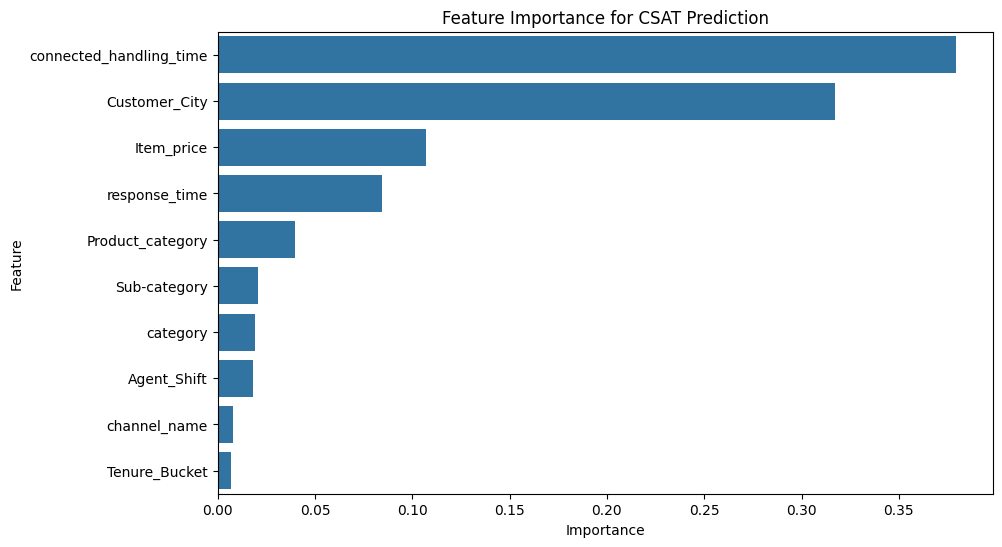

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)

plt.title("Feature Importance for CSAT Prediction")

plt.show()

In [34]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Predicted CSAT Score:", prediction[0])
print("Actual CSAT Score:", y_test.iloc[0])

Predicted CSAT Score: 4.19
Actual CSAT Score: 3


In [35]:
import pickle

# save trained model
with open("csat_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [36]:
with open("csat_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Prediction from saved model:", prediction[0])

Prediction from saved model: 4.19


In [37]:
from google.colab import files

files.download("csat_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>